# 03 · Predicting Sox17 and T from the BMP4 mask

Using what notebook 01 established:

- context features out to σ = 240px, because a 90px receptive field leaves most cells
  with a constant input — but no further, because larger scales become position
  proxies that do not transfer between wells;
- the **prior-corrected** two-part head (`models.train.train_calibrated`), because the
  re-balanced classifier prior otherwise inflates every prediction ~5× and drives R²
  negative while leaving AUROC untouched;
- scores read against the **oracle ceiling** from notebook 01, not against 1.0.

The notebook fits an A → B → C ablation so each fix can be attributed separately, then
evaluates the final model on a held-out region and a held-out well.

Config **C**'s fits (the one that matters) are cached to disk as they're trained
(`recipe.load_or_fit`, keyed by well/marker/split) -- notebooks 04, 05 and 06 default
to this exact well/feature-set, and will load these checkpoints instead of retraining
them if this notebook has already run. Delete a checkpoint under `results/models/` to
force a refit.

In [1]:
import sys, os
sys.path.append('../src')

%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tools.dataset import load_well, marker_positive, IF_BACKGROUNDS, PRIMARY_WELL, MATCHED_PAIR, RESULTS
from tools.spatial import PYRAMID_SCALES
import tools.evaluation as ev
import plotting as pl

pd.set_option('display.width', 160)
plt.rcParams['figure.dpi'] = 110

In [2]:
import torch
from models import recipe
from models.graph import border_mask
from models.train import train_predictor
from models.predictors import IFPredictor
from tools.spatial import add_mask_pyramid
from tools.morphology import indices_to_mask

RUN_ABLATION = True     # set False to skip the A/B/C comparison and only fit the final model
QUICK = False           # True -> few epochs, for a fast pass through the notebook

EPOCHS = 150 if QUICK else recipe.EPOCHS
PATIENCE = 150 if QUICK else recipe.PATIENCE
# QUICK checkpoints live under a different name so a provisional 150-epoch run can
# never be silently reused as if it were the real, fully-trained one (or vice versa).
CACHE_SUFFIX = '_quick' if QUICK else ''


In [3]:
df = load_well(PRIMARY_WELL)
centroids = df[['centroid_y', 'centroid_x']].to_numpy(np.float32)
IF_COLS = ['Sox17_mean', 'T_mean']

X_MASK = recipe.mask_features(df, 'BMP4_bin', max_sigma=recipe.MAX_SIGMA, geometry=True)
X_LOCAL = ['BMP4_bin']          # what a radius=30 x 3-layer graph effectively sees

print(f'{len(df):,} cells')
print(f'final feature set ({len(X_MASK)}):')
for c in X_MASK: print('   ', c)

ceilings = pd.read_pickle(f'{RESULTS}/oracle_ceilings.pkl')
print('\noracle ceilings:', {k: {m: round(v[m],3) for m in ("r2","auroc")} for k, v in ceilings.items()})

111,511 cells
final feature set (8):
    BMP4_bin
    BMP4_bin_log_dist_pos
    BMP4_bin_log_dist_neg
    BMP4_bin_gauss_15
    BMP4_bin_gauss_30
    BMP4_bin_gauss_60
    BMP4_bin_gauss_120
    BMP4_bin_gauss_240

oracle ceilings: {'Sox17': {'r2': 0.246, 'auroc': 0.825}, 'T': {'r2': 0.444, 'auroc': 0.879}}


In [4]:
shape = (int(centroids[:,0].max())+2, int(centroids[:,1].max())+2)
valid = np.where(~border_mask(centroids, shape, recipe.RADIUS))[0]

SPLITS = {
    'random':  tuple(valid[i] for i in ev.random_split(len(valid), seed=0)),
    'blocked': tuple(valid[i] for i in ev.spatial_block_split(centroids[valid], block=800.0, seed=0)),
}
N = len(df)
MASKS = {k: tuple(indices_to_mask(i, N) for i in v) for k, v in SPLITS.items()}
for k, (tr, va, te) in SPLITS.items():
    print(f'{k:8s} train/val/test = {len(tr):,}/{len(va):,}/{len(te):,}')

random   train/val/test = 76,681/16,432/16,432
blocked  train/val/test = 76,751/17,508/15,286


## The ablation

| | features | training |
|---|---|---|
| **A** | BMP4 mask only | `train_predictor`, `lr=1e-4`, uncorrected output — the original setup |
| **B** | BMP4 mask only | `train_calibrated` — isolates the calibration + learning-rate fix |
| **C** | mask + context (σ ≤ 240px) | `train_calibrated` — adds the receptive-field fix |

A → B and B → C are *not* clean single-variable steps (A also differs in learning rate
and epoch budget, so it is undertrained). The clean isolation of the calibration effect
is the cell further down that corrects an **already-trained** model's logit and
re-scores it without retraining.

In [5]:
def fit_config(config, x_cols, y_col, split_name, cache_path=None):
    tr, va, te = SPLITS[split_name]
    trm, vam, tem = MASKS[split_name]
    if config == 'A':
        data = recipe.build_data(df, x_cols, y_col, tr, IF_BACKGROUNDS)
        torch.manual_seed(0)
        model = IFPredictor(in_channels=len(x_cols), num_outputs=1, num_layers=recipe.NUM_LAYERS,
                            hidden_channels=recipe.HIDDEN, normalize_data=False, two_part=True)
        history = train_predictor(model, data, trm, vam, epochs=EPOCHS, patience=PATIENCE,
                                  lr=1e-4, device='cpu', desc=f'A {y_col}')
        model = model.to('cpu').eval()
        with torch.no_grad():
            pred, _ = model(data['x'], data['edge_index'], data['edge_weight'])
        pred, log_w = pred.numpy().ravel(), 0.0
    elif cache_path is not None:
        # config C only -- the recommended model, worth caching since 04/05/06 reuse it
        model, data, log_w, history = recipe.load_or_fit(
            cache_path, df, x_cols, y_col, trm, vam, tr, IF_COLS, custom_background=IF_BACKGROUNDS,
            epochs=EPOCHS, patience=PATIENCE, verbose=False)
        pred = recipe.predict(model, data, log_w)
    else:
        model, data, log_w, history = recipe.fit(
            df, x_cols, y_col, trm, vam, tr, IF_COLS, custom_background=IF_BACKGROUNDS,
            epochs=EPOCHS, patience=PATIENCE, verbose=False)
        pred = recipe.predict(model, data, log_w)
    y = data['y'].numpy().ravel(); ypos = data['y_positive'].numpy().ravel()
    met = ev.evaluate(y[tem.numpy()], pred[tem.numpy()], ypos[tem.numpy()])
    return dict(model=model, data=data, log_w=log_w, history=history, pred=pred,
                y=y, ypos=ypos, metrics=met)

In [ ]:
CONFIGS = [('A  notebook as-is', 'A', X_LOCAL),
           ('B  +calibration',   'B', X_LOCAL),
           ('C  +context',       'C', X_MASK)]

rows, final = [], {}
for marker in ['Sox17', 'T']:
    y_col = f'{marker}_mean'
    for split_name in SPLITS:
        for label, cfg, cols in ([CONFIGS[-1]] if not RUN_ABLATION else CONFIGS):
            cache_path = (f'{RESULTS}/models/{PRIMARY_WELL}_mask_{marker}_{split_name}{CACHE_SUFFIX}_gnn.pt'
                         if cfg == 'C' else None)
            out = fit_config(cfg, cols, y_col, split_name, cache_path=cache_path)
            rows.append(dict(target=marker, split=split_name, config=label, **out['metrics']))
            print(f"{marker:6s} {split_name:8s} {label:20s} "
                  f"R2={out['metrics']['r2']:+.4f}  AUROC={out['metrics']['auroc']:.3f}  "
                  f"AP={out['metrics']['ap']:.3f}")
            if cfg == 'C':
                final[(marker, split_name)] = out

mask_results = pd.DataFrame(rows)
mask_results.round(4)

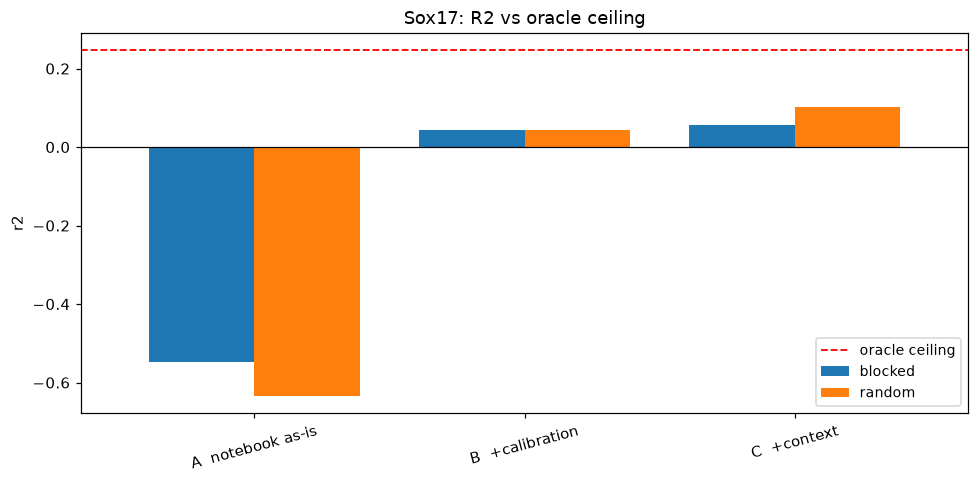

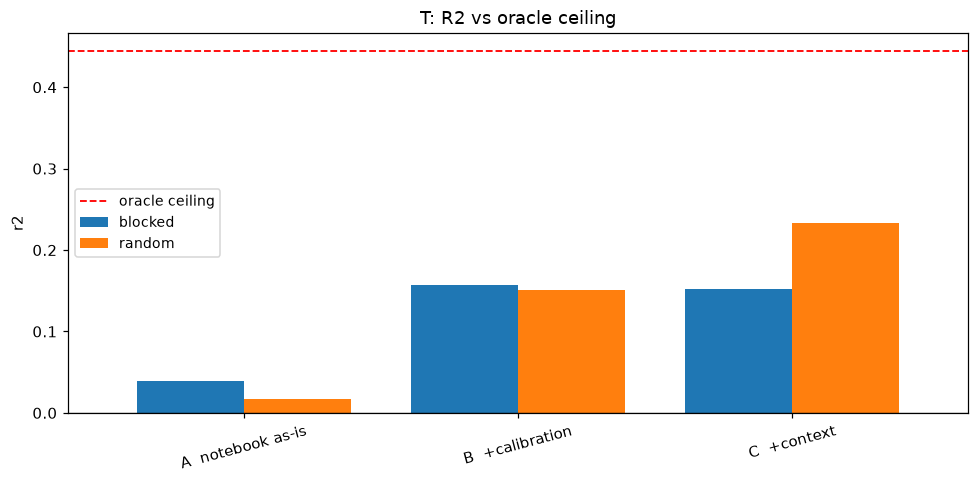

In [ ]:
for marker in ['Sox17', 'T']:
    sub = mask_results[mask_results.target == marker]
    pl.plot_metric_comparison(sub, metric='r2', group='config', hue='split',
                              ceiling=ceilings[marker]['r2'],
                              title=f'{marker}: R2 vs oracle ceiling')
    plt.show()

## The calibration effect, isolated

Take one **already-trained** model, change nothing but subtract `log(pos_weight)` from
the classifier logit, and re-score.

The correction is monotone *in the logit*, so the classifier's own ranking is
untouched. The reported output is `prob × magnitude` though, and rescaling `prob`
alone can reorder that product slightly — so AUROC moves a little rather than not at
all. It should move by <0.01 while R² moves by a lot; that asymmetry is the signature
of a pure calibration problem rather than a ranking one.

true positive rate      : 0.155
mean predicted prob     : 0.425   <- inflated by pos_weight
  after -log(w) applied : 0.149
pos_weight = 5.40   log(w) = 1.686

uncorrected  R2=-0.4499   AUROC=0.7105
corrected    R2=+0.1019   AUROC=0.7165


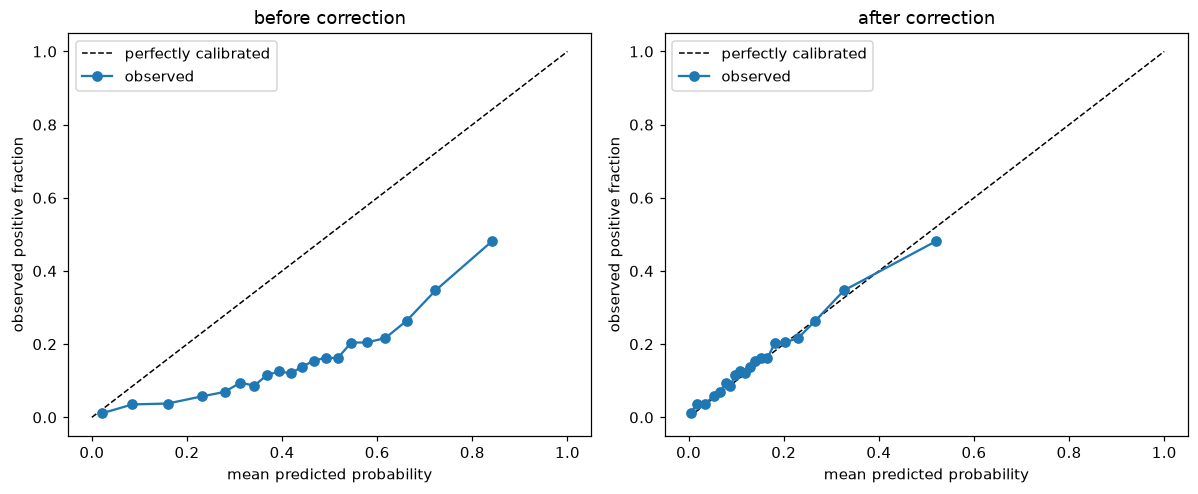

In [ ]:
out = final[('Sox17', 'random')]
model, data = out['model'], out['data']
tem = MASKS['random'][2].numpy()

with torch.no_grad():
    _, logit, magnitude, _ = model.forward_two_part(data['x'], data['edge_index'], data['edge_weight'])
prob_raw = torch.sigmoid(logit).numpy().ravel()
prob_cal = torch.sigmoid(logit - out['log_w']).numpy().ravel()
mag = magnitude.numpy().ravel()

print(f"true positive rate      : {out['ypos'][tem].mean():.3f}")
print(f"mean predicted prob     : {prob_raw[tem].mean():.3f}   <- inflated by pos_weight")
print(f"  after -log(w) applied : {prob_cal[tem].mean():.3f}")
print(f"pos_weight = {np.exp(out['log_w']):.2f}   log(w) = {out['log_w']:.3f}\n")
from sklearn.metrics import r2_score, roc_auc_score
for name, p in [('uncorrected', prob_raw * mag), ('corrected', prob_cal * mag)]:
    print(f'{name:12s} R2={r2_score(out["y"][tem], p[tem]):+.4f}   '
          f'AUROC={roc_auc_score(out["ypos"][tem], p[tem]):.4f}')

fig, axs = plt.subplots(1, 2, figsize=(11, 4.6))
pl.plot_calibration(out['ypos'][tem], prob_raw[tem], ax=axs[0], title='before correction')
pl.plot_calibration(out['ypos'][tem], prob_cal[tem], ax=axs[1], title='after correction')
plt.tight_layout(); plt.show()

## The final model

Sox17: loaded from a cached checkpoint -- no training-curve history to plot


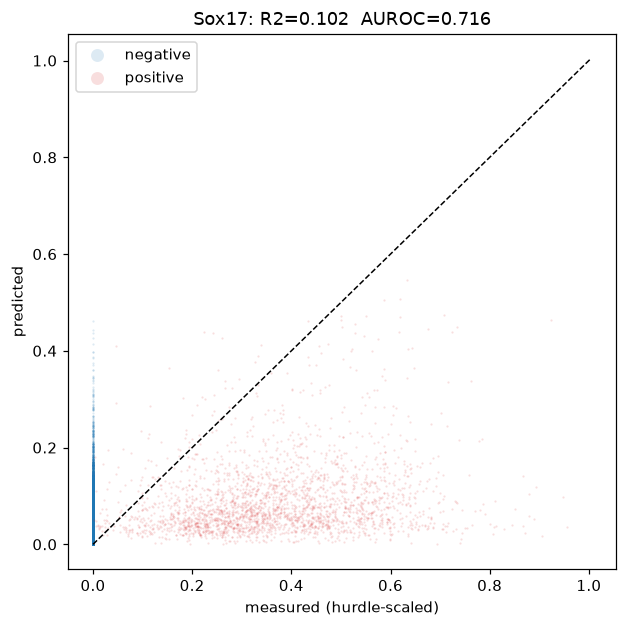

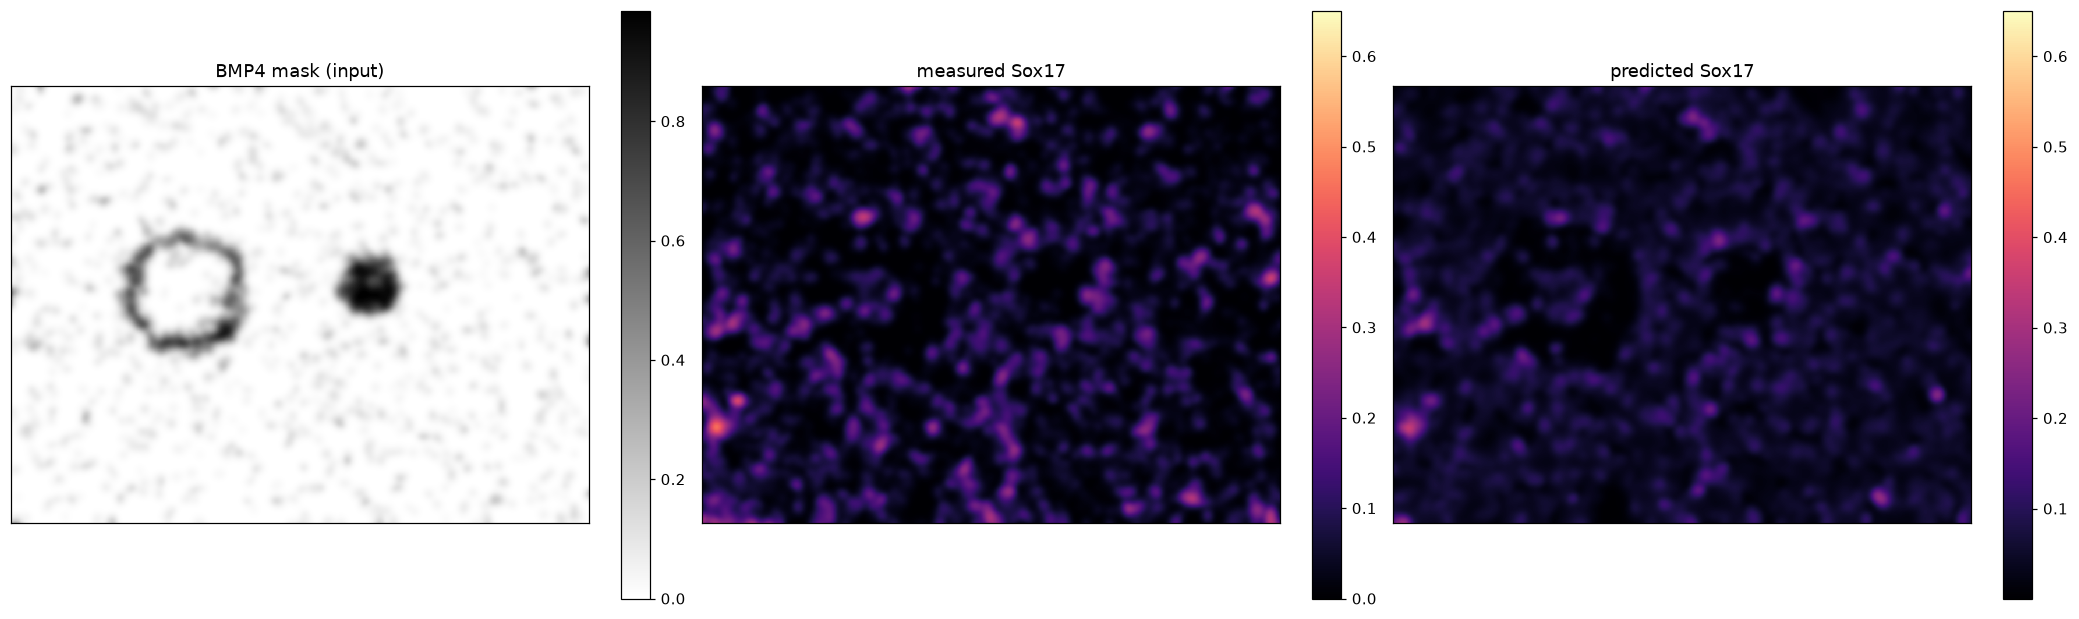

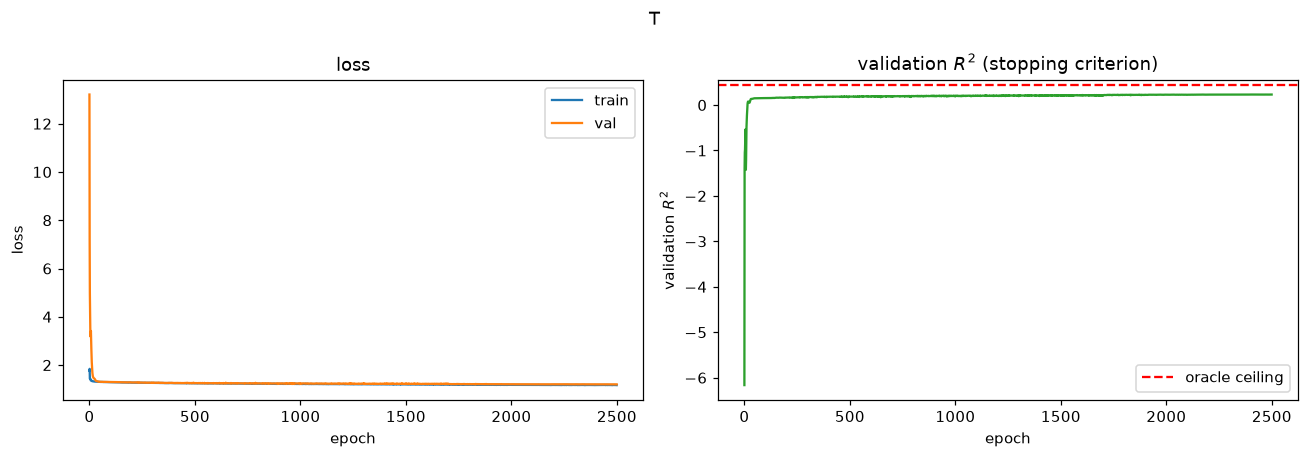

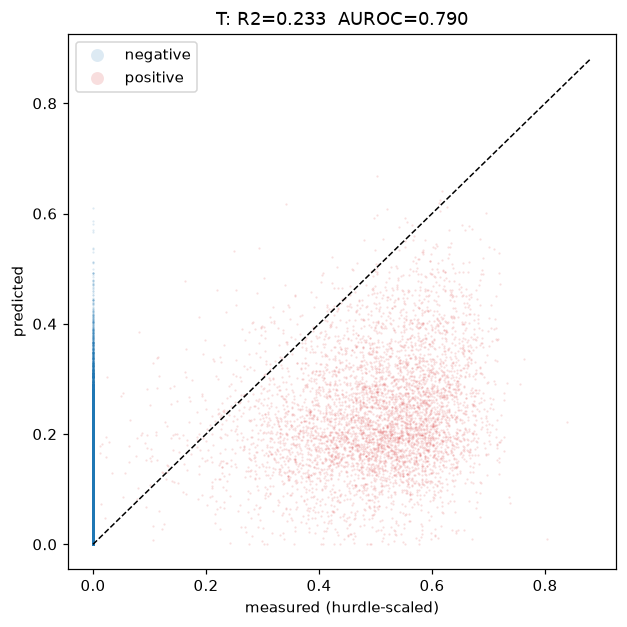

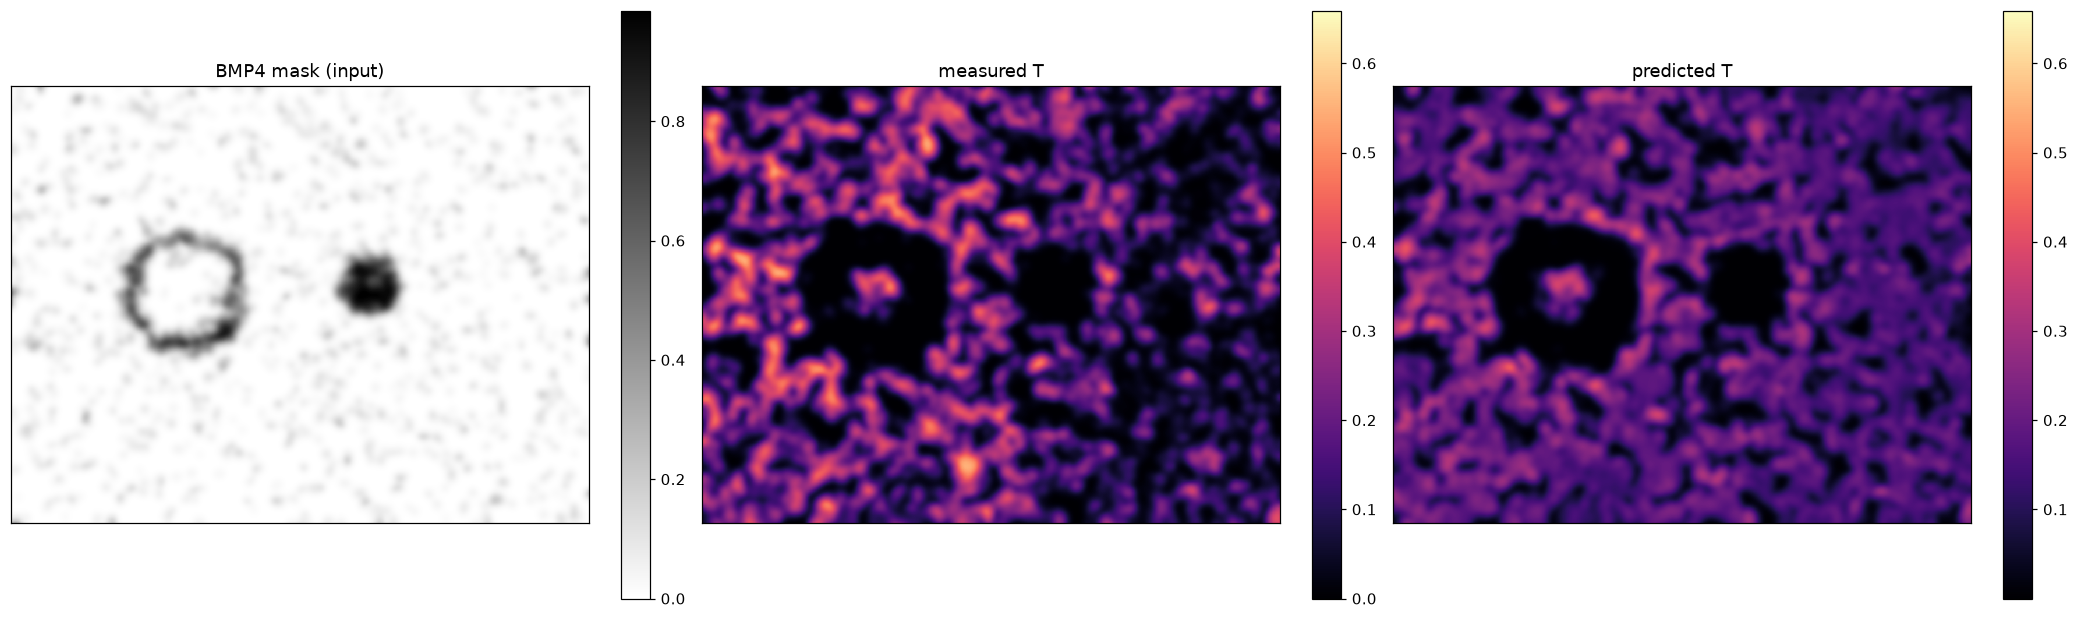

In [ ]:
for marker in ['Sox17', 'T']:
    out = final[(marker, 'random')]
    if out['history'] is not None:
        pl.plot_training_curves(out['history'], ceiling=ceilings[marker]['r2'], title=marker)
        plt.show()
    else:
        print(f'{marker}: loaded from a cached checkpoint -- no training-curve history to plot')

    tem = MASKS['random'][2].numpy()
    fig, ax = plt.subplots(figsize=(5.8, 5.8))
    pl.plot_pred_vs_actual(out['y'][tem], out['pred'][tem], out['ypos'][tem], ax=ax,
                           title=f"{marker}: R2={out['metrics']['r2']:.3f}  AUROC={out['metrics']['auroc']:.3f}")
    plt.tight_layout(); plt.show()

    pl.plot_prediction_panel(df, 'BMP4_bin', out['y'], out['pred'], target_name=marker,
                             mask_name='BMP4 mask (input)', smooth_sigma=60)
    plt.show()

## Held-out well

`W9_pattern1` was imaged at the same illumination power in the same session as
`W8_pattern1` — the only pair in `data/stitched` where a transfer score measures
biology rather than batch.

Scored with Spearman ρ against **raw** intensity, which is invariant to whatever
positive/negative threshold W9 would need. Only W8_pattern1's threshold is verified.

In [ ]:
from scipy.stats import spearmanr

df9 = load_well(MATCHED_PAIR[1])
add_mask_pyramid(df9, 'BMP4_bin', geometry=True)

transfer = []
for marker in ['Sox17', 'T']:
    out = final[(marker, 'random')]
    d9 = recipe.build_data(df9, X_MASK, f'{marker}_mean', np.arange(len(df9)), IF_BACKGROUNDS)
    d9['x'] = torch.from_numpy(out['data']['x_scaler'].transform(df9[X_MASK].to_numpy(np.float32)))
    p9 = recipe.predict(out['model'], d9, out['log_w'])
    rho_self = spearmanr(out['pred'], df[f'{marker}_mean']).statistic
    rho_w9 = spearmanr(p9, df9[f'{marker}_mean']).statistic
    transfer.append(dict(target=marker, rho_train_well=rho_self, rho_heldout_well=rho_w9))
    print(f'{marker:6s} rho  W8_pattern1 (train) = {rho_self:+.3f}   W9_pattern1 (held out) = {rho_w9:+.3f}')

pd.DataFrame(transfer).round(3)

Sox17  rho  W8_pattern1 (train) = +0.434   W9_pattern1 (held out) = +0.268
T      rho  W8_pattern1 (train) = +0.675   W9_pattern1 (held out) = +0.416


,target,rho_train_well,rho_heldout_well
0,Sox17,0.434,0.268
1,T,0.675,0.416


## Save

The config-C checkpoints themselves were already saved during fitting above (one
per marker/split, via `recipe.load_or_fit`) -- only the results tables need saving
here.

In [ ]:
mask_results.to_csv(f'{RESULTS}/03_markers_from_mask.csv', index=False)
pd.DataFrame(transfer).to_csv(f'{RESULTS}/03_transfer.csv', index=False)
print(f'saved -> {RESULTS}/03_markers_from_mask.csv')
print(f'saved -> {RESULTS}/03_transfer.csv')

saved -> /Users/allywang/Desktop/work/F2026/OptoBMP/results/03_markers_from_mask.csv
saved -> /Users/allywang/Desktop/work/F2026/OptoBMP/results/03_transfer.csv


## Read-out

Both fixes matter and they are independent: the prior correction rescues R² while
leaving AUROC essentially where it was, and the context features move both.

With `QUICK = True` the models are trained for a tenth of the epochs they need, so
treat the absolute numbers as provisional — set `QUICK = False` for the real ones.

But these numbers **cannot yet be attributed to BMP4 signalling** — notebook 02 showed
the mask also predicts cell density, and the graph itself supplies density through its
weighted-sum aggregation. Notebook 04 runs the control that separates the two.